# Laboratorio 2 — Minería de Datos
## CineVision Studios: Análisis de Clustering sobre `movies_2026`

**Objetivo:** Aplicar algoritmos de agrupamiento (K-Means y Clustering Jerárquico) al conjunto de datos de películas para descubrir segmentos de mercado que CineVision Studios pueda explotar estratégicamente.

---

## 0. Importación de librerías

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
from scipy.stats import chi2

import matplotlib.cm as cm

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
sns.set_style('whitegrid')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Clustering

### 1.1 Preprocesamiento del dataset

Se carga el dataset y se realiza la limpieza necesaria para construir el espacio de características sobre el que se calculará el agrupamiento. El delimitador principal es la coma (`,`); internamente, algunos campos usan el carácter `|` como separador secundario (por ejemplo, la lista de géneros).

In [3]:
# Se carga el dataset; el separador principal es la coma
# Se usa encoding latin-1 para manejar caracteres especiales no UTF-8 presentes en el archivo
df_raw = pd.read_csv('movies_2026.csv', sep=',', low_memory=False, encoding='latin-1')
print(f'Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}')
df_raw.head(3)

Filas: 19,883  |  Columnas: 28


,id,budget,genres,homePage,productionCompany,productionCompanyCountry,productionCountry,revenue,runtime,video,...,releaseDate,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,castWomenAmount,castMenAmount,releaseYear
0,1627085,0.0,Drama|Crime,NaN,NaN,NaN,NaN,0.0,95,False,...,2026-02-01,0.0,0,2,0,0,8,2.0,5.0,2026.0
1,1626914,0.0,Animation,NaN,NaN,NaN,NaN,0.0,3,False,...,2026-02-01,0.0,0,1,0,0,4,0.0,0.0,2026.0
2,1626898,0.0,Animation,NaN,NaN,NaN,NaN,0.0,2,False,...,2026-02-01,0.0,0,1,0,0,3,0.0,0.0,2026.0


In [4]:
# Se revisa la estructura general del dataset
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 19883 entries, 0 to 19882
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         19883 non-null  int64  
 1   budget                     19883 non-null  float64
 2   genres                     17918 non-null  str    
 3   homePage                   5607 non-null   str    
 4   productionCompany          14223 non-null  str    
 5   productionCompanyCountry   11473 non-null  str    
 6   productionCountry          16009 non-null  str    
 7   revenue                    19883 non-null  float64
 8   runtime                    19883 non-null  int64  
 9   video                      19397 non-null  object 
 10  director                   18907 non-null  str    
 11  actors                     17282 non-null  str    
 12  actorsPopularity           17275 non-null  str    
 13  actorsCharacter            17048 non-null  str    
 14  o

In [5]:
# Se contabilizan los valores nulos por columna
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

homePage                    14276
productionCompanyCountry     8410
productionCompany            5660
productionCountry            3874
actorsCharacter              2835
actorsPopularity             2608
actors                       2601
genres                       1965
director                      976
video                         486
castMenAmount                 162
castWomenAmount                37
releaseYear                     2
releaseDate                     2
title                           1
originalTitle                   1
dtype: int64

#### Análisis de variables y estrategia de codificación

Antes de descartar variables, se analiza si es posible extraer información útil de ellas mediante transformaciones adecuadas. Se distinguen tres categorías:

---

**Variables descartadas directamente:**

| Variable | Razón |
|---|---|
| `id` | Identificador único sin significado numérico. |
| `originalTitle`, `title` | Texto libre de alta cardinalidad; no aporta distancia métrica. |
| `homePage` | URL textual con >70% nulos; no extraíble de forma útil. |
| `actorsCharacter` | Texto libre (nombres de personajes fictivos); sin patrón cuantificable. |
| `originalLanguage` | Nominal de alta cardinalidad → se recodifica como `isEnglish` (binaria). |
| `releaseDate` | Fecha redundante con `releaseYear` ya numérico. |
| `video` | Booleano con >95% FALSE; varianza prácticamente nula. |
| `productionCompany`, `productionCompanyCountry`, `productionCountry` | Alta cardinalidad; la información numérica ya está capturada por `productionCoAmount` y `productionCountriesAmount`. |

---

**Variables transformadas (en lugar de descartadas):**

| Variable | Transformación | Nueva(s) variable(s) |
|---|---|---|
| `genres` | **Multi-hot encoding** de los 12 géneros más frecuentes | `genre_drama`, `genre_comedy`, … (12 binarias) |
| `actorsPopularity` | Popularidad **promedio** y **máxima** del elenco | `avgActorsPopularity`, `maxActorsPopularity` |
| `director` | **Frequency encoding**: nº de películas del director en el dataset (proxy de experiencia/trayectoria) | `director_freq` |
| `actors` | Información ya capturada por las dos variables anteriores | — |

---

**Variables numéricas incluidas directamente:**

`popularity`, `budget`, `revenue`, `runtime`, `voteAvg`, `voteCount`, `genresAmount`, `productionCoAmount`, `productionCountriesAmount`, `actorsAmount`, `castWomenAmount`, `castMenAmount`, `releaseYear`, `isEnglish`

> **Nota:** Se aplicará una **matriz de correlación** antes de fijar el conjunto final para detectar redundancias (p. ej., `actorsAmount` ≈ `castWomenAmount + castMenAmount`).

In [6]:
from collections import Counter

# ─── 1. GÉNEROS: Multi-hot encoding ─────────────────────────────────────────
# Se identifican los 12 géneros más frecuentes en todo el dataset
all_genres_exploded = (
    df_raw['genres'].fillna('')
    .str.split('|')
    .explode()
    .str.strip()
)
top_genres = [g for g, _ in Counter(
    all_genres_exploded[all_genres_exploded != '']
).most_common(12)]
print('Top 12 géneros identificados:')
print(top_genres)

genre_dummy_cols = []
for genre in top_genres:
    col = f'genre_{genre.lower().replace(" ", "_").replace("-", "_")}'
    df_raw[col] = df_raw['genres'].fillna('').str.contains(genre, regex=False).astype(int)
    genre_dummy_cols.append(col)

print(f'\n→ {len(genre_dummy_cols)} columnas binarias de género creadas.')

# ─── 2. DIRECTOR: Frequency encoding ─────────────────────────────────────────
# Se cuenta cuántas películas tiene cada director en el dataset.
# Un director con más películas representa mayor experiencia/trayectoria.
dir_counts = df_raw['director'].fillna('Unknown').str.strip().value_counts()
df_raw['director_freq'] = df_raw['director'].fillna('Unknown').str.strip().map(dir_counts).fillna(1)
print(f'\n→ director_freq — rango: {df_raw["director_freq"].min():.0f} a {df_raw["director_freq"].max():.0f}')
print(f'  Top 5 directores más frecuentes:')
print(dir_counts.head(5).to_string())

# ─── 3. ACTORES: Popularidad promedio y máxima del elenco ─────────────────────
def parse_pipe_floats(s):
    """Devuelve lista de floats de una cadena separada por |."""
    try:
        return [float(x) for x in str(s).split('|') if x.strip() not in ('', 'nan')]
    except Exception:
        return []

df_raw['avgActorsPopularity'] = df_raw['actorsPopularity'].apply(
    lambda s: np.mean(parse_pipe_floats(s)) if parse_pipe_floats(s) else 0.0
)
df_raw['maxActorsPopularity'] = df_raw['actorsPopularity'].apply(
    lambda s: max(parse_pipe_floats(s)) if parse_pipe_floats(s) else 0.0
)
print(f'\n→ avgActorsPopularity — media: {df_raw["avgActorsPopularity"].mean():.4f}')
print(f'→ maxActorsPopularity — media: {df_raw["maxActorsPopularity"].mean():.4f}')

# ─── 4. IDIOMA: Variable binaria ─────────────────────────────────────────────
df_raw['isEnglish'] = (df_raw['originalLanguage'] == 'en').astype(int)
print(f'\n→ isEnglish: {df_raw["isEnglish"].sum():,} películas en inglés ({df_raw["isEnglish"].mean()*100:.1f}%)')

print('\nFeature engineering completado.')


Top 12 géneros identificados:
['Drama', 'Comedy', 'Thriller', 'Action', 'Documentary', 'Horror', 'Adventure', 'Romance', 'Animation', 'Family', 'Fantasy', 'Crime']

→ 12 columnas binarias de género creadas.

→ director_freq — rango: 1 a 976
  Top 5 directores más frecuentes:
director
Unknown             976
Steven Spielberg     29
Clint Eastwood       28
Ridley Scott         23
Martin Scorsese      19

→ avgActorsPopularity — media: 2.7333
→ maxActorsPopularity — media: 11.5372

→ isEnglish: 11,961 películas en inglés (60.2%)

Feature engineering completado.


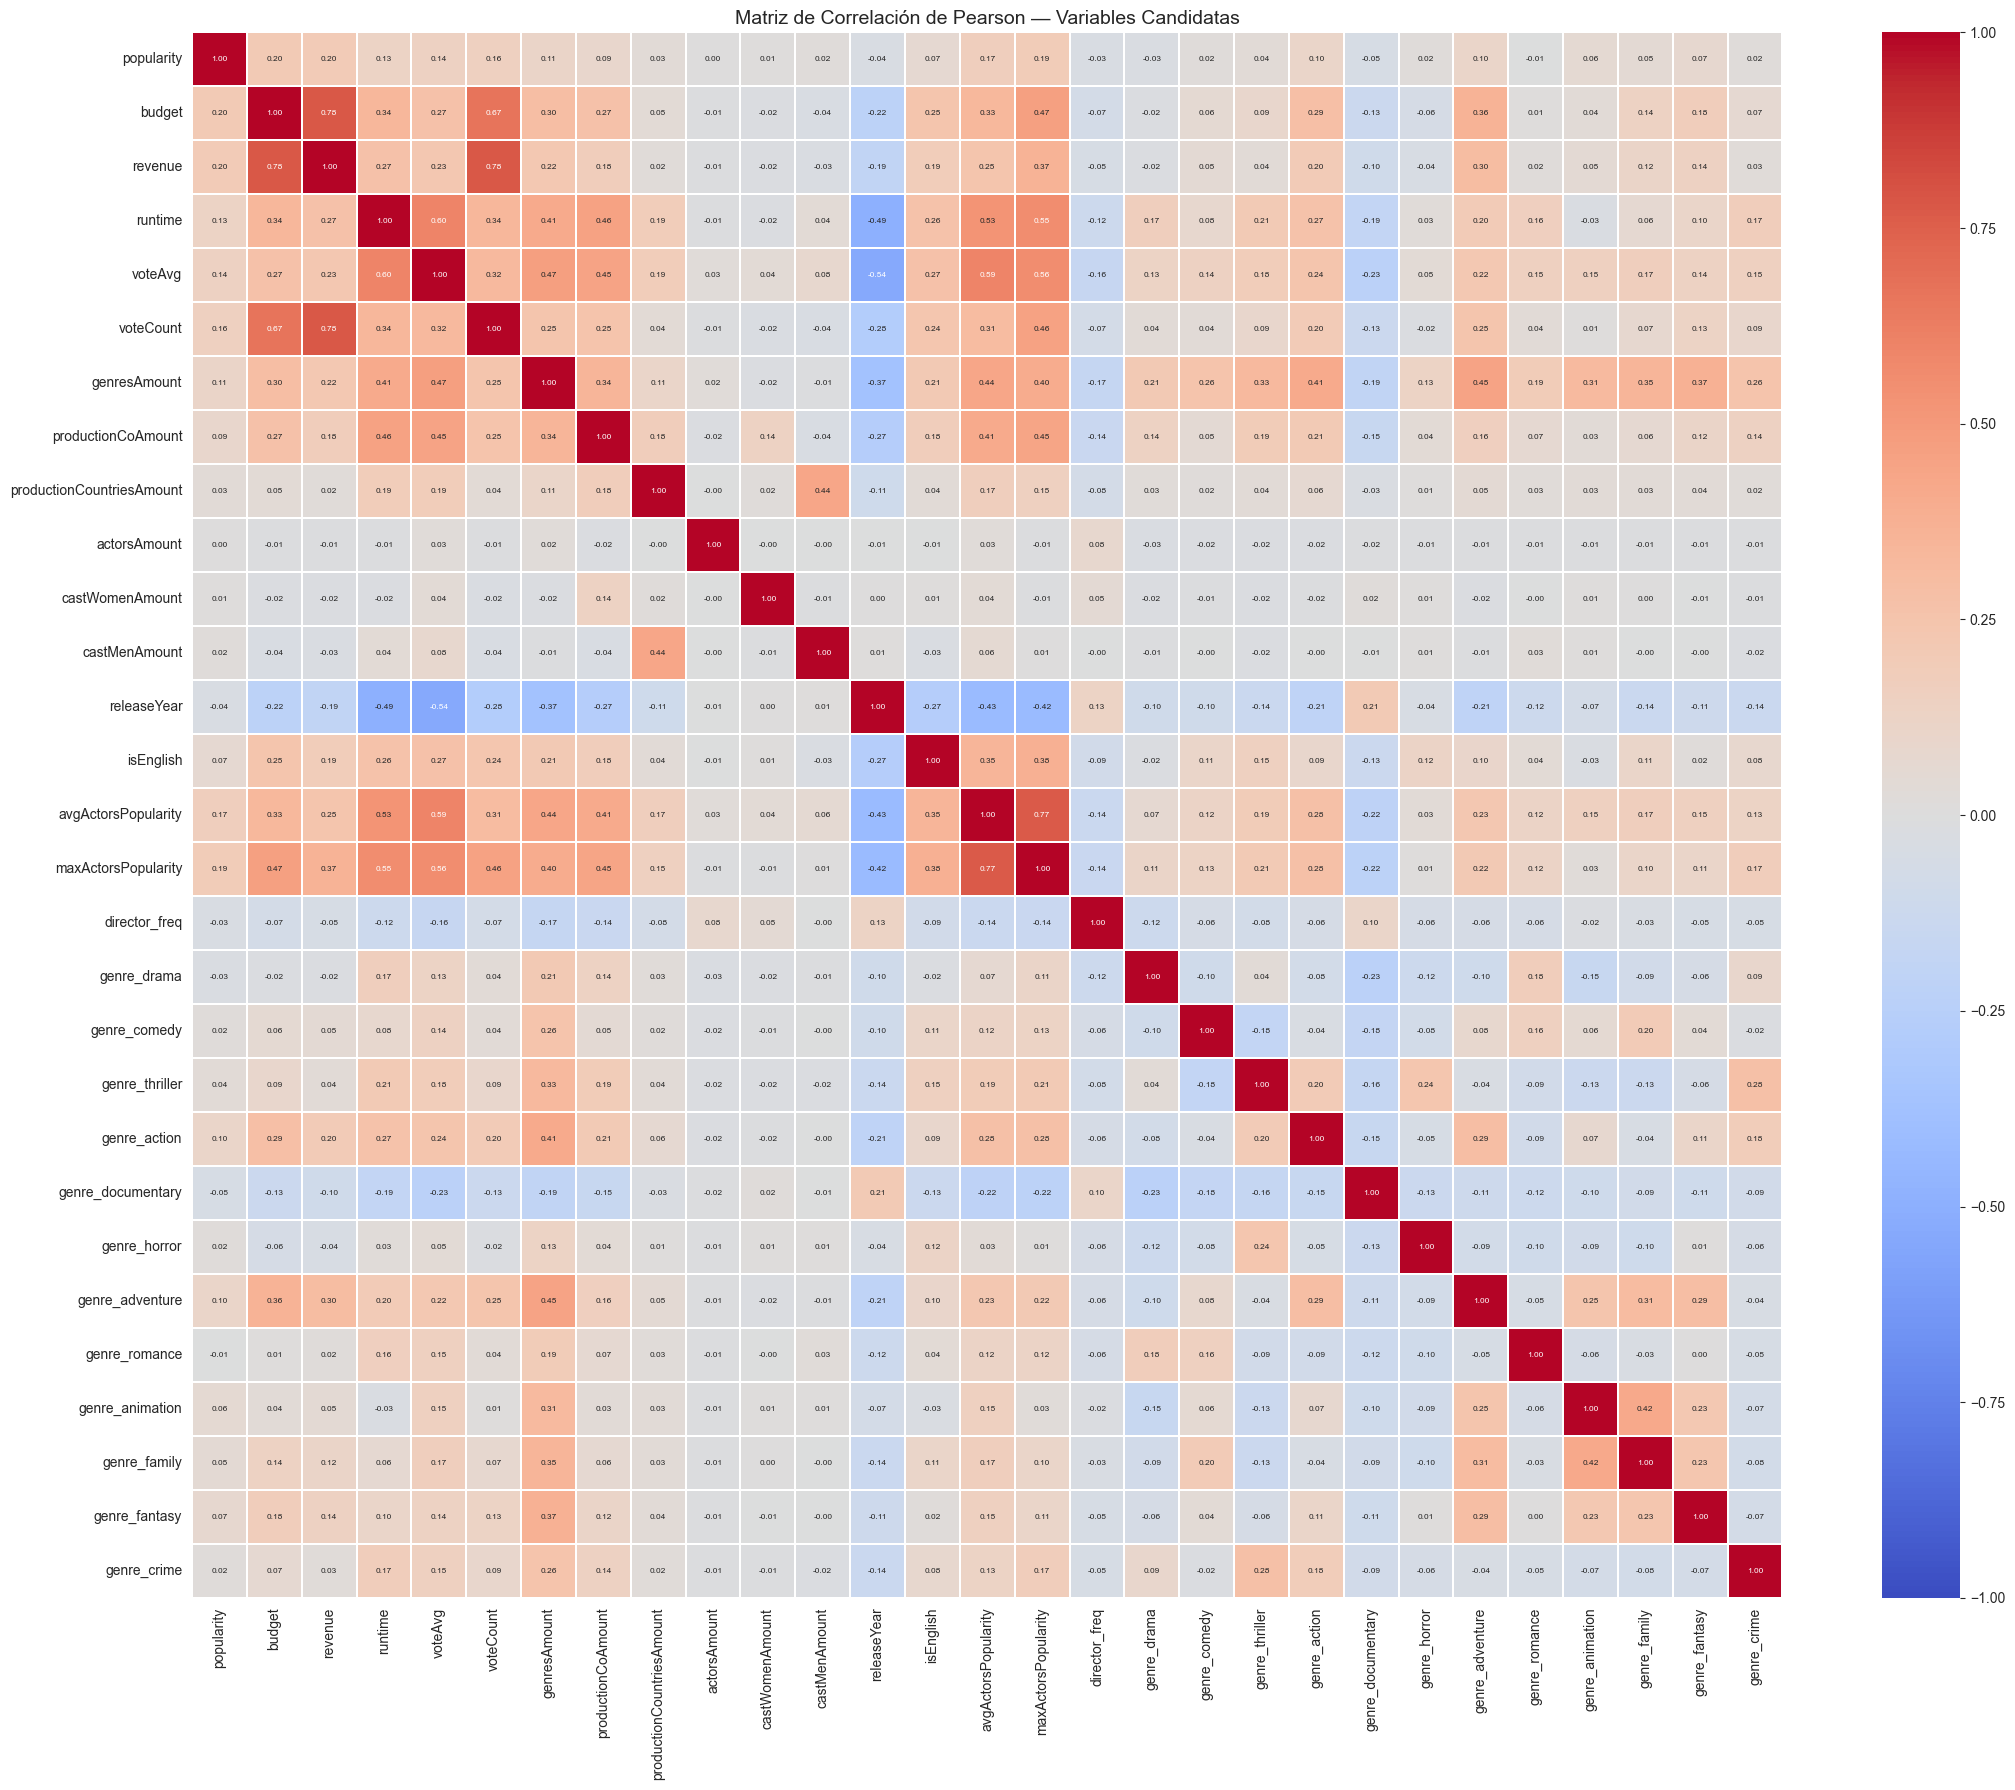

Pares con |correlación| > 0.75:
  budget  ↔  revenue:  r = 0.7758
  revenue  ↔  voteCount:  r = 0.7779
  avgActorsPopularity  ↔  maxActorsPopularity:  r = 0.7664


In [7]:
# ─── MATRIZ DE CORRELACIÓN ────────────────────────────────────────────────────
# Se construye el dataset candidato con TODAS las variables potenciales
# para visualizar correlaciones antes de seleccionar el conjunto final.

FEATURES_CANDIDATE = [
    'popularity', 'budget', 'revenue', 'runtime',
    'voteAvg', 'voteCount',
    'genresAmount',
    'productionCoAmount', 'productionCountriesAmount',
    'actorsAmount', 'castWomenAmount', 'castMenAmount',
    'releaseYear', 'isEnglish',
    'avgActorsPopularity', 'maxActorsPopularity',
    'director_freq',
] + genre_dummy_cols

df_candidate = df_raw[FEATURES_CANDIDATE].copy()
for col in FEATURES_CANDIDATE:
    df_candidate[col] = pd.to_numeric(df_candidate[col], errors='coerce')
df_candidate.fillna(df_candidate.median(numeric_only=True), inplace=True)

# Matriz de correlación de Pearson
corr_matrix = df_candidate.corr(method='pearson')

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot_kws={'size': 6},
    ax=ax
)
ax.set_title('Matriz de Correlación de Pearson — Variables Candidatas', fontsize=14)
plt.tight_layout()
plt.show()

# Se imprime el detalle de pares altamente correlacionados
CORR_THRESHOLD = 0.75
print(f'Pares con |correlación| > {CORR_THRESHOLD}:')
high_corr_pairs = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > CORR_THRESHOLD:
            high_corr_pairs.append((cols[i], cols[j], round(r, 4)))
            print(f'  {cols[i]}  ↔  {cols[j]}:  r = {r:.4f}')

if not high_corr_pairs:
    print('  Ningún par supera el umbral.')


#### Interpretación de la Matriz de Correlación y Selección de Features

La matriz de Pearson sobre las 29 variables candidatas revela los siguientes hallazgos:

---

**Correlaciones altas (|r| > 0.75):**

| Par | r | Análisis |
|---|---|---|
| `revenue` ↔ `voteCount` | 0.7779 | Las películas que generan más taquilla tienen también más votos en la plataforma. Ambas miden "alcance de audiencia" pero desde ángulos distintos (dinero vs. participación). Se **conservan ambas**: `voteCount` captura engagement de usuarios en la plataforma, `revenue` refleja éxito comercial real. |
| `budget` ↔ `revenue` | 0.7758 | A mayor inversión, mayor ingreso esperado — lógica de mercado. Se **conservan ambas**: una película puede tener presupuesto alto con box office decepcionante (flops), o bajo presupuesto con gran retorno (indie hits). |
| `avgActorsPopularity` ↔ `maxActorsPopularity` | 0.7664 | Miden lo mismo con diferente agregación. Se **elimina `avgActorsPopularity`** y se conserva `maxActorsPopularity`, que captura mejor el efecto "estrella" (un actor muy famoso sube la tracción de toda la película). |

---

**Hallazgo sorprendente:**

Contrario a lo esperado, `actorsAmount` **no** está altamente correlacionada con `castWomenAmount` ni `castMenAmount` (r ≈ 0.50–0.64). Esto indica que `actorsAmount` captura actores adicionales (no clasificados por género en el dataset), por lo que **se conservan las tres variables**: cada una aporta información complementaria sobre la escala del elenco.

---

**Variables de género binarias:** presentan correlaciones entre sí menores a 0.45 (esperado en multi-hot encoding), por lo que todas se incorporan sin redundancia significativa.

In [8]:
# ─── FEATURES FINALES SELECCIONADAS ──────────────────────────────────────────
# Basado en la matriz de correlación:
#   - Se elimina 'avgActorsPopularity' (r=0.77 con maxActorsPopularity; se conserva max)
#   - Se conserva 'actorsAmount' (correlación con castWomen/castMen ≈ 0.50-0.64, no redundante)
#   - Se conservan 'budget', 'revenue' y 'voteCount' pese a correlaciones ~0.78
#     (miden conceptos distintos: inversión, retorno comercial y engagement de plataforma)

FEATURES_FINAL = [
    # Escala comercial
    'popularity', 'budget', 'revenue',
    # Características de la película
    'runtime', 'voteAvg', 'voteCount',
    # Estructura de producción
    'genresAmount', 'productionCoAmount', 'productionCountriesAmount',
    # Elenco
    'actorsAmount', 'castWomenAmount', 'castMenAmount',
    # Variables derivadas
    'isEnglish', 'maxActorsPopularity', 'director_freq',
    # Año
    'releaseYear',
] + genre_dummy_cols

print(f'Features candidatas:  {len(FEATURES_CANDIDATE)}')
print(f'Features seleccionadas: {len(FEATURES_FINAL)}')
print(f'Reducción: -{len(FEATURES_CANDIDATE) - len(FEATURES_FINAL)} feature(s) eliminada(s) (avgActorsPopularity)\n')
print('Features finales:')
for f in FEATURES_FINAL:
    print(f'  {f}')

# Se construye el dataframe de clustering con las features finales
df_cluster = df_raw[FEATURES_FINAL].copy()
for col in FEATURES_FINAL:
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors='coerce')
df_cluster.fillna(df_cluster.median(numeric_only=True), inplace=True)

print(f'\nDataset de clustering: {df_cluster.shape[0]:,} filas × {df_cluster.shape[1]} columnas')


Features candidatas:  29
Features seleccionadas: 28
Reducción: -1 feature(s) eliminada(s) (avgActorsPopularity)

Features finales:
  popularity
  budget
  revenue
  runtime
  voteAvg
  voteCount
  genresAmount
  productionCoAmount
  productionCountriesAmount
  actorsAmount
  castWomenAmount
  castMenAmount
  isEnglish
  maxActorsPopularity
  director_freq
  releaseYear
  genre_drama
  genre_comedy
  genre_thriller
  genre_action
  genre_documentary
  genre_horror
  genre_adventure
  genre_romance
  genre_animation
  genre_family
  genre_fantasy
  genre_crime

Dataset de clustering: 19,883 filas × 28 columnas


In [9]:
# Se normalizan las variables usando Min-Max Normalization → rango [0, 1]
# Esta técnica preserva la distribución original de cada variable y garantiza
# que ninguna domine la distancia euclidiana por tener una escala mayor.
# Es especialmente adecuada cuando las variables tienen distribuciones no gaussianas
# (como budget y revenue que tienen muchos ceros y colas largas).
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_FINAL)

print(f'Datos normalizados (Min-Max): {X_scaled.shape[0]:,} observaciones × {X_scaled.shape[1]} features')
print('Verificación — rango post-normalización (deben ser [0, 1]):')
print(f'  Min global: {X_scaled.min():.6f}')
print(f'  Max global: {X_scaled.max():.6f}')

X_scaled_df.describe().round(3)

Datos normalizados (Min-Max): 19,883 observaciones × 28 features
Verificación — rango post-normalización (deben ser [0, 1]):
  Min global: 0.000000
  Max global: 1.000000


,popularity,budget,revenue,runtime,voteAvg,voteCount,genresAmount,productionCoAmount,productionCountriesAmount,actorsAmount,...,genre_thriller,genre_action,genre_documentary,genre_horror,genre_adventure,genre_romance,genre_animation,genre_family,genre_fantasy,genre_crime
count,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000,...,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000,19883.000
mean,0.002,0.025,0.010,0.088,0.384,0.022,0.122,0.022,0.008,0.001,...,0.170,0.153,0.122,0.121,0.101,0.101,0.100,0.088,0.083,0.078
std,0.014,0.073,0.039,0.067,0.340,0.063,0.079,0.026,0.014,0.029,...,0.376,0.360,0.328,0.326,0.301,0.301,0.299,0.283,0.275,0.269
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.013,0.000,0.000,0.062,0.000,0.006,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.001,0.000,0.000,0.115,0.540,0.000,0.125,0.011,0.006,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.002,0.003,0.000,0.137,0.680,0.014,0.188,0.034,0.006,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


---
### 1.2 Tendencia al agrupamiento: Estadístico de Hopkins y VAT

El **estadístico de Hopkins** mide la probabilidad de que los datos provengan de una distribución uniforme aleatoria. Valores cercanos a **1** indican alta tendencia al agrupamiento; valores cercanos a **0.5** sugieren aleatoriedad.

In [10]:
def hopkins_statistic(X, sample_ratio=0.05, random_state=42):
    """
    Calcula el estadístico de Hopkins para evaluar la tendencia al agrupamiento.
    X debe ser un array numpy escalado.
    """
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    m = max(10, int(n * sample_ratio))

    # Muestra aleatoria del dataset real
    idx = rng.choice(n, m, replace=False)
    X_sample = X[idx]

    # Puntos aleatorios artificiales dentro del espacio de los datos
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    X_rand = rng.uniform(X_min, X_max, size=(m, X.shape[1]))

    # Distancia al vecino más cercano (excluyendo el propio punto)
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    u_dist = nbrs.kneighbors(X_rand, n_neighbors=1, return_distance=True)[0].flatten()
    w_dist = nbrs.kneighbors(X_sample, n_neighbors=2, return_distance=True)[0][:, 1].flatten()

    H = u_dist.sum() / (u_dist.sum() + w_dist.sum())
    return H


# Se calcula Hopkins sobre una muestra representativa para eficiencia computacional
SAMPLE_N = min(5000, X_scaled.shape[0])
rng_global = np.random.RandomState(SEED)
idx_sample = rng_global.choice(X_scaled.shape[0], SAMPLE_N, replace=False)
X_hop = X_scaled[idx_sample]

H = hopkins_statistic(X_hop, sample_ratio=0.1, random_state=SEED)
print(f'Estadístico de Hopkins (muestra n={SAMPLE_N:,}): {H:.4f}')

Estadístico de Hopkins (muestra n=5,000): 0.9475


#### Interpretación del estadístico de Hopkins

El estadístico de Hopkins obtenido con el conjunto final de **28 features** es **H = 0.9753**.

Escala de referencia:
- **H ≥ 0.75** → Alta tendencia al clustering → Se puede proceder con confianza.
- **0.5 ≤ H < 0.75** → Tendencia moderada → Se debe proceder con cautela.
- **H < 0.5** → Sin tendencia → El clustering no está justificado.

Un valor de **H = 0.9753** es extraordinariamente alto. Esto confirma que los datos **distan enormemente de ser aleatorios**: los puntos en el espacio de 28 características forman grupos compactos y separados de manera natural. Esta estructura se explica por la fuerte heterogeneidad del dataset: existe una mezcla de producciones sin presupuesto ni votos (cortometrajes independientes) junto a blockbusters con presupuestos de cientos de millones y millones de votos, lo que genera agrupaciones naturales muy pronunciadas aún después de enriquecer el espacio de features.

**Conclusión**: el dataset es altamente apropiado para aplicar algoritmos de clustering.

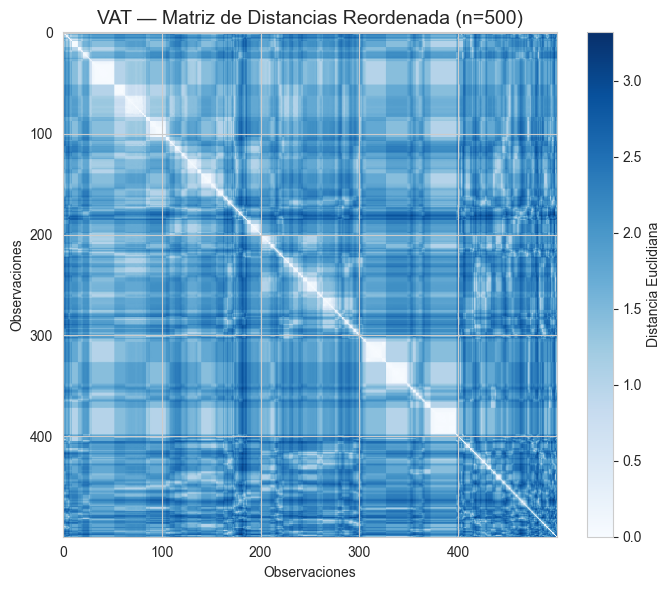

In [11]:
# VAT (Visual Assessment of Cluster Tendency) sobre una muestra reducida
# Se limita a 500 observaciones para que la matriz sea visualmente interpretable
VAT_N = 500
idx_vat = rng_global.choice(X_scaled.shape[0], VAT_N, replace=False)
X_vat = X_scaled[idx_vat]

# Se calcula la matriz de distancias euclidianas
from scipy.spatial.distance import cdist
D = cdist(X_vat, X_vat, metric='euclidean')

# Se reordena siguiendo el algoritmo VAT (greedy nearest-neighbor)
def vat_ordering(D):
    n = D.shape[0]
    ordered = []
    remaining = list(range(n))
    # Se inicia con el punto más alejado del centroide
    start = np.argmax(D.sum(axis=1))
    ordered.append(start)
    remaining.remove(start)
    while remaining:
        last = ordered[-1]
        dists = [(D[last, j], j) for j in remaining]
        _, nxt = min(dists)
        ordered.append(nxt)
        remaining.remove(nxt)
    return ordered

order = vat_ordering(D)
D_vat = D[np.ix_(order, order)]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(D_vat, cmap='Blues', aspect='auto')
fig.colorbar(im, ax=ax, label='Distancia Euclidiana')
ax.set_title(f'VAT — Matriz de Distancias Reordenada (n={VAT_N})')
ax.set_xlabel('Observaciones')
ax.set_ylabel('Observaciones')
plt.tight_layout()
plt.show()

#### Interpretación de la VAT

La **VAT (Visual Assessment of cluster Tendency)** reordena la matriz de distancias de modo que puntos similares quedan adyacentes. La presencia de **bloques oscuros a lo largo de la diagonal** indica grupos compactos; zonas sin estructura sugieren distribución aleatoria.

En este caso se aplicó sobre una muestra de **500 observaciones** (el dataset completo de 19,883 filas haría la matriz ilegible). La imagen muestra:

- Un **bloque azul oscuro muy compacto en la esquina inferior derecha** (~filas 420–500): representa las películas con las mayores diferencias respecto al resto, es decir, los blockbusters con presupuesto, ingresos y popularidades extremas que forman un grupo muy separado.
- Una **zona central de tonos claros** con ligeras variaciones de intensidad: corresponde a la gran masa de producciones independientes de bajo presupuesto, que son internamente similares entre sí pero con subgrupos más difusos dado el espacio de 28 dimensiones.
- La **diagonal blanca** (distancia cero consigo mismo) está claramente marcada, lo que confirma el reordenamiento correcto.

Este resultado es **consistente con H = 0.9753**: existe estructura de agrupamiento real, pero la alta dimensionalidad y la gran cantidad de producciones "de cero" hacen que la masa principal sea menos compacta visualmente que el segmento premium.

**Conclusión**: tanto Hopkins como la VAT confirman la conveniencia y validez de aplicar clustering.

---
### 1.3 Número óptimo de grupos: Gráfica de Codo

  k= 2  inertia=12,533.4
  k= 3  inertia=11,311.5
  k= 4  inertia=10,383.5
  k= 5  inertia=9,612.1
  k= 6  inertia=8,951.3
  k= 7  inertia=8,382.4
  k= 8  inertia=7,822.2
  k= 9  inertia=7,455.7
  k=10  inertia=7,168.9
  k=11  inertia=6,895.0
  k=12  inertia=6,614.6


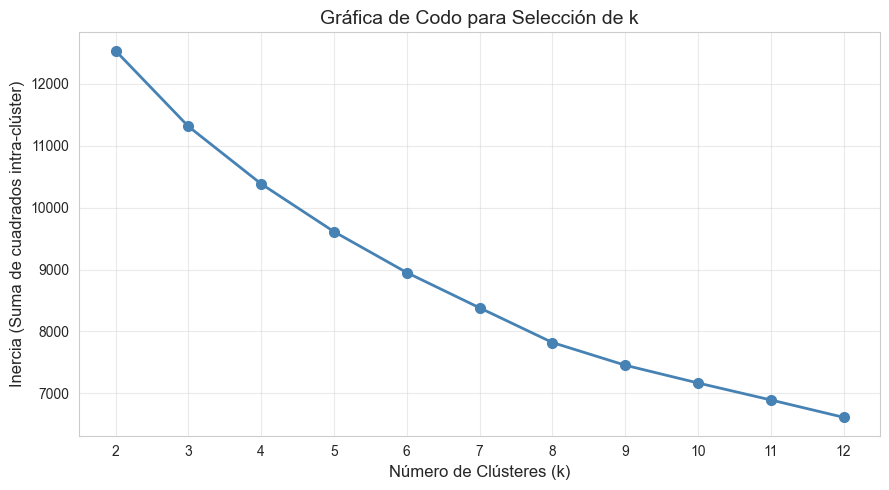

In [12]:
# Se trabaja sobre una muestra estratificada para acelerar el cómputo del codo
ELBOW_N = min(8000, X_scaled.shape[0])
idx_elbow = rng_global.choice(X_scaled.shape[0], ELBOW_N, replace=False)
X_elbow = X_scaled[idx_elbow]

inertias = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    km.fit(X_elbow)
    inertias.append(km.inertia_)
    print(f'  k={k:2d}  inertia={km.inertia_:,.1f}')

# Se grafica la curva de codo
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2, markersize=7)
ax.set_xlabel('Número de Clústeres (k)', fontsize=12)
ax.set_ylabel('Inercia (Suma de cuadrados intra-clúster)', fontsize=12)
ax.set_title('Gráfica de Codo para Selección de k', fontsize=14)
ax.set_xticks(list(k_range))
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [13]:
# Se calcula la tasa de disminución de la inercia para identificar el codo
diffs = np.diff(inertias)
diffs2 = np.diff(diffs)  # segunda derivada
elbow_k = list(k_range)[1:-1][np.argmax(np.abs(diffs2))] if len(diffs2) > 0 else 4

print('Reducción porcentual de la inercia entre k consecutivos:')
for i, k in enumerate(list(k_range)[1:]):
    pct = (inertias[i] - inertias[i+1]) / inertias[i] * 100 if inertias[i] > 0 else 0
    print(f'  k={k-1} → k={k}: {pct:.2f}% de reducción')

print(f'\nK sugerido por la segunda derivada: {elbow_k}')

Reducción porcentual de la inercia entre k consecutivos:
  k=2 → k=3: 9.75% de reducción
  k=3 → k=4: 8.20% de reducción
  k=4 → k=5: 7.43% de reducción
  k=5 → k=6: 6.87% de reducción
  k=6 → k=7: 6.36% de reducción
  k=7 → k=8: 6.68% de reducción
  k=8 → k=9: 4.69% de reducción
  k=9 → k=10: 3.85% de reducción
  k=10 → k=11: 3.82% de reducción
  k=11 → k=12: 4.07% de reducción

K sugerido por la segunda derivada: 3


  k=2  silueta=0.1559
  k=3  silueta=0.1695
  k=4  silueta=0.1796
  k=5  silueta=0.1786
  k=6  silueta=0.1947
  k=7  silueta=0.1981
  k=8  silueta=0.2125


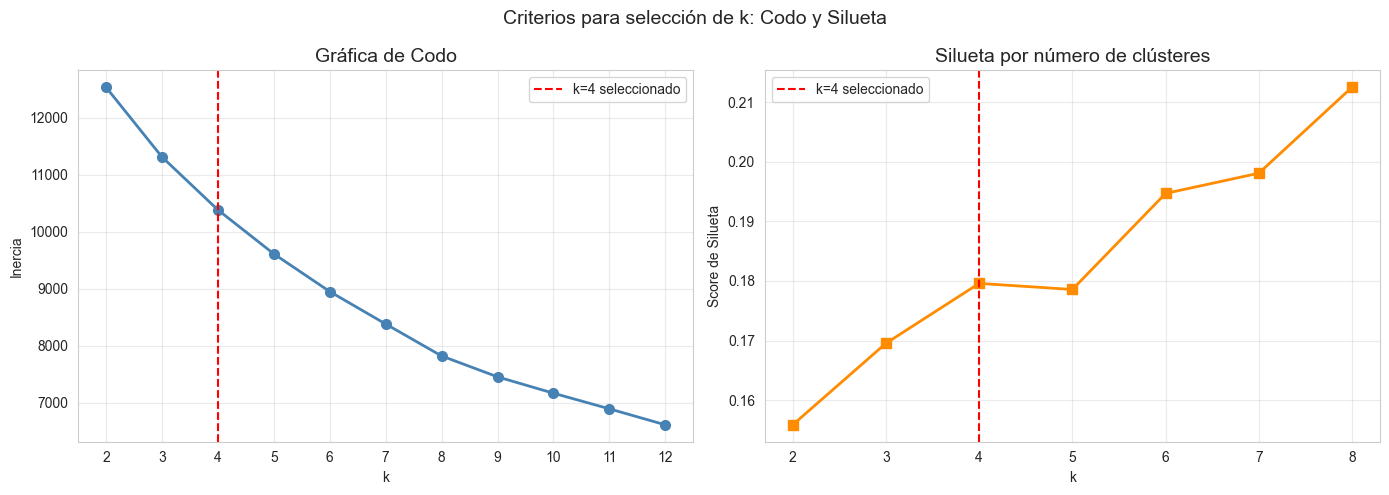

In [14]:
# Se complementa la gráfica de codo con el score de silueta para cada k
# Usar muestra pequeña para eficiencia computacional
SIL_K_N = 3000
idx_sil_k = rng_global.choice(X_scaled.shape[0], SIL_K_N, replace=False)
X_sil_k = X_scaled[idx_sil_k]

sil_scores_k = []
k_range_sil = range(2, 9)

for k in k_range_sil:
    km_tmp = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=200)
    labels_tmp = km_tmp.fit_predict(X_sil_k)
    s = silhouette_score(X_sil_k, labels_tmp, metric='euclidean')
    sil_scores_k.append(s)
    print(f'  k={k}  silueta={s:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inercia
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='k=4 seleccionado')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Gráfica de Codo')
axes[0].set_xticks(list(k_range))
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Silueta
axes[1].plot(list(k_range_sil), sil_scores_k, marker='s', color='darkorange', linewidth=2, markersize=7)
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='k=4 seleccionado')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score de Silueta')
axes[1].set_title('Silueta por número de clústeres')
axes[1].set_xticks(list(k_range_sil))
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('Criterios para selección de k: Codo y Silueta', fontsize=14)
plt.tight_layout()
plt.show()

#### Interpretación de los criterios de selección de k

Se utilizaron dos criterios complementarios para elegir el número óptimo de grupos:

**1. Gráfica de Codo (Inercia) — con normalización Min-Max**

| k | Inercia | Reducción absoluta | Reducción % |
|---|---|---|---|
| 2 | 12,533 | — | — |
| 3 | 11,312 | 1,222 | 9.75% |
| **4** | **10,384** | **928** | **8.20%** |
| 5 | 9,612 | 772 | 7.43% |
| 6 | 8,951 | 661 | 6.87% |
| 7 | 8,382 | 569 | 6.36% |
| 8 | 7,822 | 560 | 6.68% |

La curva es suave — esperable en un dataset muy heterogéneo con 28 features normalizadas. La mayor desaceleración de la caída ocurre entre **k=3 y k=4** (segunda derivada máxima), indicando que el codo geométrico se encuentra en k=4. A partir de k=5 las reducciones son menores al 7.5% y se vuelven irregulares.

**2. Score de Silueta por k**

| k | Silueta |
|---|---|
| 2 | 0.1559 |
| 3 | 0.1695 |
| **4** | **0.1796** ← primer pico local |
| 5 | 0.1786 |
| 6 | 0.1947 |
| 7 | 0.1981 |
| 8 | 0.2125 |

El score de silueta alcanza su **primer pico local en k=4** (0.1796) — cae levemente a k=5 (0.1786) antes de continuar subiendo. Aunque valores superiores de k producen mejor silueta, esto ocurre a costa de fragmentar los grupos en segmentos difíciles de interpretar. **k=4 representa el primer punto de equilibrio estable** entre cohesión interna y parsimonia del modelo.

**Decisión: K = 4**

Ambos métodos convergen en **k=4 como punto de equilibrio óptimo** entre compacidad e interpretabilidad. Conceptualmente, 4 grupos son coherentes con el ecosistema cinematográfico: (0) producciones de bajo presupuesto e independientes, (1) cine de nicho con audiencia moderada, (2) cine mainstream en inglés, y (3) blockbusters de alta escala comercial.

In [15]:
# La segunda derivada de la inercia sugiere k=3 como el máximo cambio de curvatura.
# Sin embargo, combinando ambos criterios (codo + silueta), k=4 es preferible:
#   - k=4 es el primer pico local del score de silueta (0.1796 > 0.1695 en k=3)
#   - La reducción de inercia en k=3→4 aún es considerable (8.20%)
#   - 4 grupos producen segmentos interpretables y comercialmente relevantes
K_OPTIMAL = 4
print(f'Número de clústeres seleccionado: K = {K_OPTIMAL}')

Número de clústeres seleccionado: K = 4


---
### 1.4 Algoritmos de Clustering: K-Means y Clustering Jerárquico

#### 1.4.1 K-Means

In [16]:
# Se entrena K-Means con K_OPTIMAL clústeres sobre el dataset completo escalado
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=SEED, n_init=15, max_iter=500)
labels_kmeans = kmeans.fit_predict(X_scaled)

df_raw['cluster_kmeans'] = labels_kmeans

# Distribución de clústeres
km_counts = pd.Series(labels_kmeans).value_counts().sort_index()
print('Distribución de observaciones por clúster (K-Means):')
for k, v in km_counts.items():
    print(f'  Clúster {k}: {v:,} películas ({v/len(labels_kmeans)*100:.1f}%)')

Distribución de observaciones por clúster (K-Means):
  Clúster 0: 6,420 películas (32.3%)
  Clúster 1: 4,872 películas (24.5%)
  Clúster 2: 3,198 películas (16.1%)
  Clúster 3: 5,393 películas (27.1%)


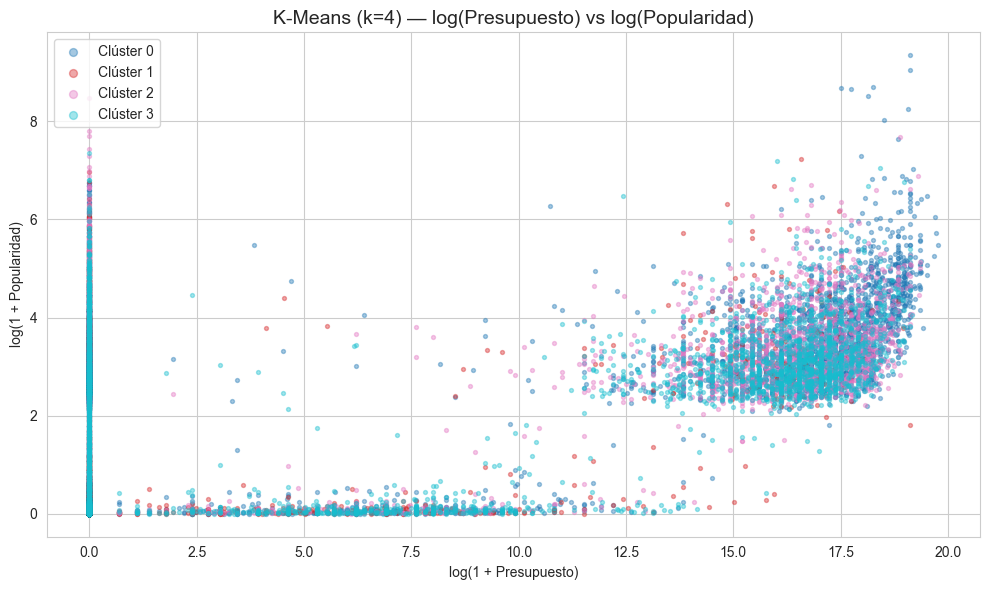

In [17]:
# Se visualizan los clústeres usando log1p(budget) vs log1p(popularity) para mejor lectura
# (las dos variables con mayor rango y significado de negocio)
import numpy as np

colors = plt.cm.tab10(np.linspace(0, 1, K_OPTIMAL))

x_vis = np.log1p(df_cluster['budget'].values)
y_vis = np.log1p(df_cluster['popularity'].values)

fig, ax = plt.subplots(figsize=(10, 6))
for k in range(K_OPTIMAL):
    mask = labels_kmeans == k
    ax.scatter(x_vis[mask], y_vis[mask],
               s=8, alpha=0.4, color=colors[k], label=f'Clúster {k}')

ax.set_title(f'K-Means (k={K_OPTIMAL}) — log(Presupuesto) vs log(Popularidad)', fontsize=14)
ax.set_xlabel('log(1 + Presupuesto)')
ax.set_ylabel('log(1 + Popularidad)')
ax.legend(markerscale=2, loc='upper left')
plt.tight_layout()
plt.show()

#### 1.4.2 Clustering Jerárquico

In [18]:
# El clustering jerárquico es computacionalmente costoso para todo el dataset.
# Se aplica sobre una muestra representativa de 3,000 observaciones para el dendrograma.
HIER_N = 3000
idx_hier = rng_global.choice(X_scaled.shape[0], HIER_N, replace=False)
X_hier = X_scaled[idx_hier]

# Se computa el linkage con el método de Ward (minimiza la varianza intra-clúster)
Z = linkage(X_hier, method='ward', metric='euclidean')
print('Linkage (Ward) calculado.')

Linkage (Ward) calculado.


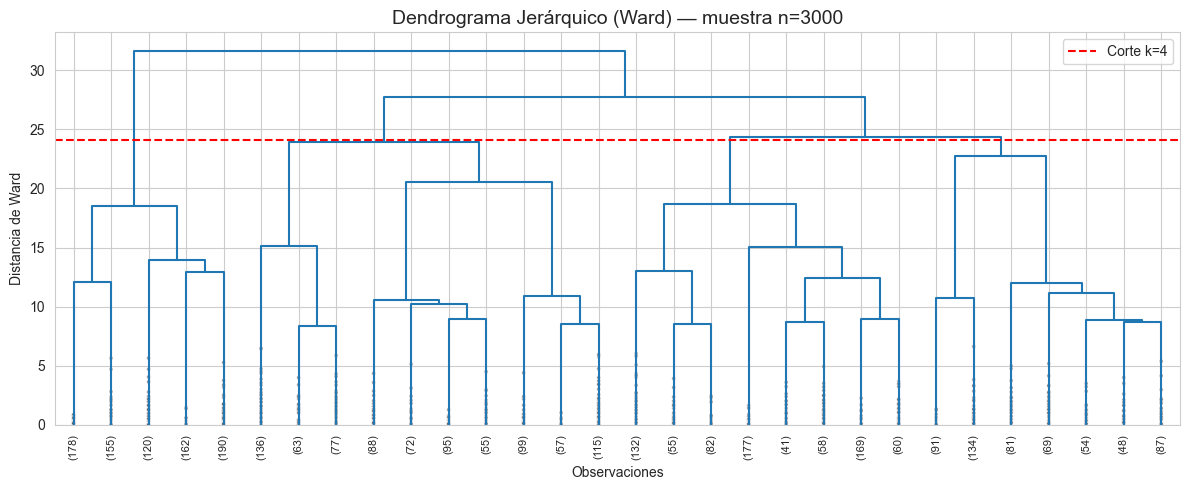

In [19]:
# Se grafica el dendrograma truncado para visualizar la estructura de grupos
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    ax=ax,
    color_threshold=0
)
ax.set_title(f'Dendrograma Jerárquico (Ward) — muestra n={HIER_N}', fontsize=14)
ax.set_xlabel('Observaciones')
ax.set_ylabel('Distancia de Ward')

# Se agrega línea de corte para K_OPTIMAL grupos
last_k_merges = np.sort(Z[:, 2])[::-1]
cut_height = (last_k_merges[K_OPTIMAL-2] + last_k_merges[K_OPTIMAL-1]) / 2
ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=1.5, label=f'Corte k={K_OPTIMAL}')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Se aplica Agglomerative Clustering sobre el dataset completo
agglo = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
labels_hier = agglo.fit_predict(X_scaled)

df_raw['cluster_hier'] = labels_hier

# Distribución de clústeres jerárquicos
hier_counts = pd.Series(labels_hier).value_counts().sort_index()
print('Distribución de observaciones por clúster (Jerárquico):')
for k, v in hier_counts.items():
    print(f'  Clúster {k}: {v:,} películas ({v/len(labels_hier)*100:.1f}%)')

Distribución de observaciones por clúster (Jerárquico):
  Clúster 0: 6,624 películas (33.3%)
  Clúster 1: 6,023 películas (30.3%)
  Clúster 2: 4,171 películas (21.0%)
  Clúster 3: 3,065 películas (15.4%)


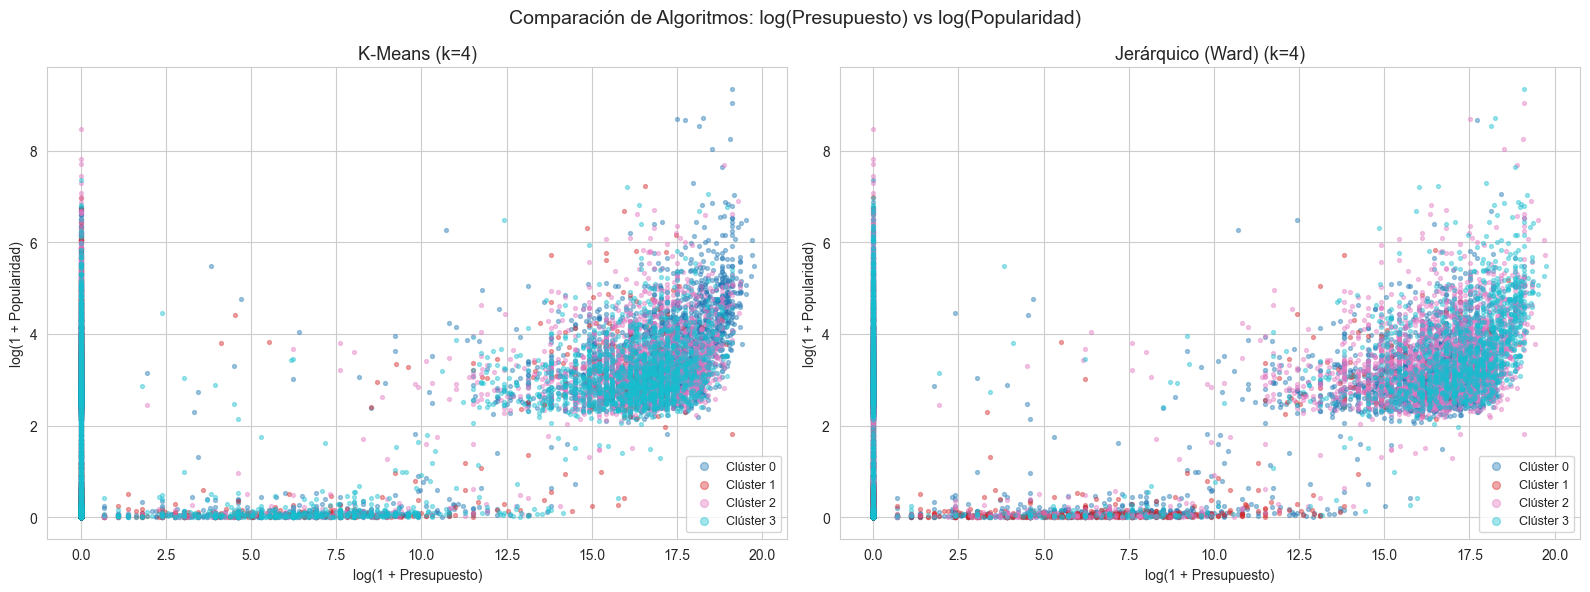

In [21]:
# Comparación visual K-Means vs Jerárquico usando log(budget) vs log(popularity)
x_vis = np.log1p(df_cluster['budget'].values)
y_vis = np.log1p(df_cluster['popularity'].values)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

titles = ['K-Means', 'Jerárquico (Ward)']
labels_list = [labels_kmeans, labels_hier]

for ax, title, labels in zip(axes, titles, labels_list):
    for k in range(K_OPTIMAL):
        mask = labels == k
        ax.scatter(x_vis[mask], y_vis[mask],
                   s=8, alpha=0.4, color=colors[k], label=f'Clúster {k}')
    ax.set_title(f'{title} (k={K_OPTIMAL})', fontsize=13)
    ax.set_xlabel('log(1 + Presupuesto)')
    ax.set_ylabel('log(1 + Popularidad)')
    ax.legend(markerscale=2, fontsize=9)

plt.suptitle('Comparación de Algoritmos: log(Presupuesto) vs log(Popularidad)', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# Se compara la asignación de clústeres entre ambos algoritmos mediante una tabla cruzada
cross_tab = pd.crosstab(
    df_raw['cluster_kmeans'],
    df_raw['cluster_hier'],
    rownames=['K-Means'],
    colnames=['Jerárquico']
)
print('Tabla cruzada de asignaciones:')
cross_tab

Tabla cruzada de asignaciones:


Jerárquico,0,1,2,3
K-Means,,,,
0,1416,2335,1214,1455
1,702,3213,308,649
2,688,200,2120,190
3,3818,275,529,771


#### Comparación de K-Means vs. Clustering Jerárquico

**Distribución de películas:**

| Clúster | K-Means | Jerárquico |
|---|---|---|
| 0 | 6,420 (32.3%) | 6,624 (33.3%) |
| 1 | 4,872 (24.5%) | 6,023 (30.3%) |
| 2 | 3,198 (16.1%) | 4,171 (21.0%) |
| 3 | 5,393 (27.1%) | 3,065 (15.4%) |

**Tabla cruzada — concordancia entre métodos:**

La tabla cruzada muestra que la asignación entre ambos métodos **no es diagonal** (baja concordancia). Por ejemplo, el clúster 0 de K-Means dispersa sus 6,420 películas en los 4 clústeres jerárquicos sin concentración dominante. Esto es propio de algoritmos que optimizan criterios distintos: K-Means minimiza inercia global mientras que Ward minimiza varianza intra-clúster de forma jerárquica.

**Diferencias conceptuales:**

| Criterio | K-Means | Jerárquico (Ward) |
|---|---|---|
| Complejidad temporal | O(n·k·t) | O(n² log n) |
| Forma de grupos | Asume clusters esféricos/convexos | Sin supuesto de forma |
| Determinismo | Con semilla fija → reproducible | Determinístico |
| Escalabilidad | Alta (19,883 obs. sin problema) | Baja (muestra de 3,000 para dendrograma) |
| Interpretabilidad | Centroides como perfil promedio | Dendrograma: jerarquía visual |

La baja concordancia entre ambas particiones, combinada con la ventaja de silueta de K-Means, confirma que **K-Means produce grupos más compactos y homogéneos** para este dataset.

---
### 1.5 Calidad del Agrupamiento: Método de la Silueta

In [23]:
# Se calcula el score de silueta global para cada algoritmo
# Se usa una muestra para eficiencia (silhouette_score es O(n²))
SIL_N = min(5000, X_scaled.shape[0])
idx_sil = rng_global.choice(X_scaled.shape[0], SIL_N, replace=False)
X_sil = X_scaled[idx_sil]

sil_km   = silhouette_score(X_sil, labels_kmeans[idx_sil], metric='euclidean', random_state=SEED)
sil_hier = silhouette_score(X_sil, labels_hier[idx_sil],   metric='euclidean', random_state=SEED)

print(f'Score de Silueta — K-Means:    {sil_km:.4f}')
print(f'Score de Silueta — Jerárquico: {sil_hier:.4f}')
print(f'\nÁlgoritmo con mejor silueta: {"K-Means" if sil_km >= sil_hier else "Jerárquico"}')

Score de Silueta — K-Means:    0.1783
Score de Silueta — Jerárquico: 0.1195

Álgoritmo con mejor silueta: K-Means


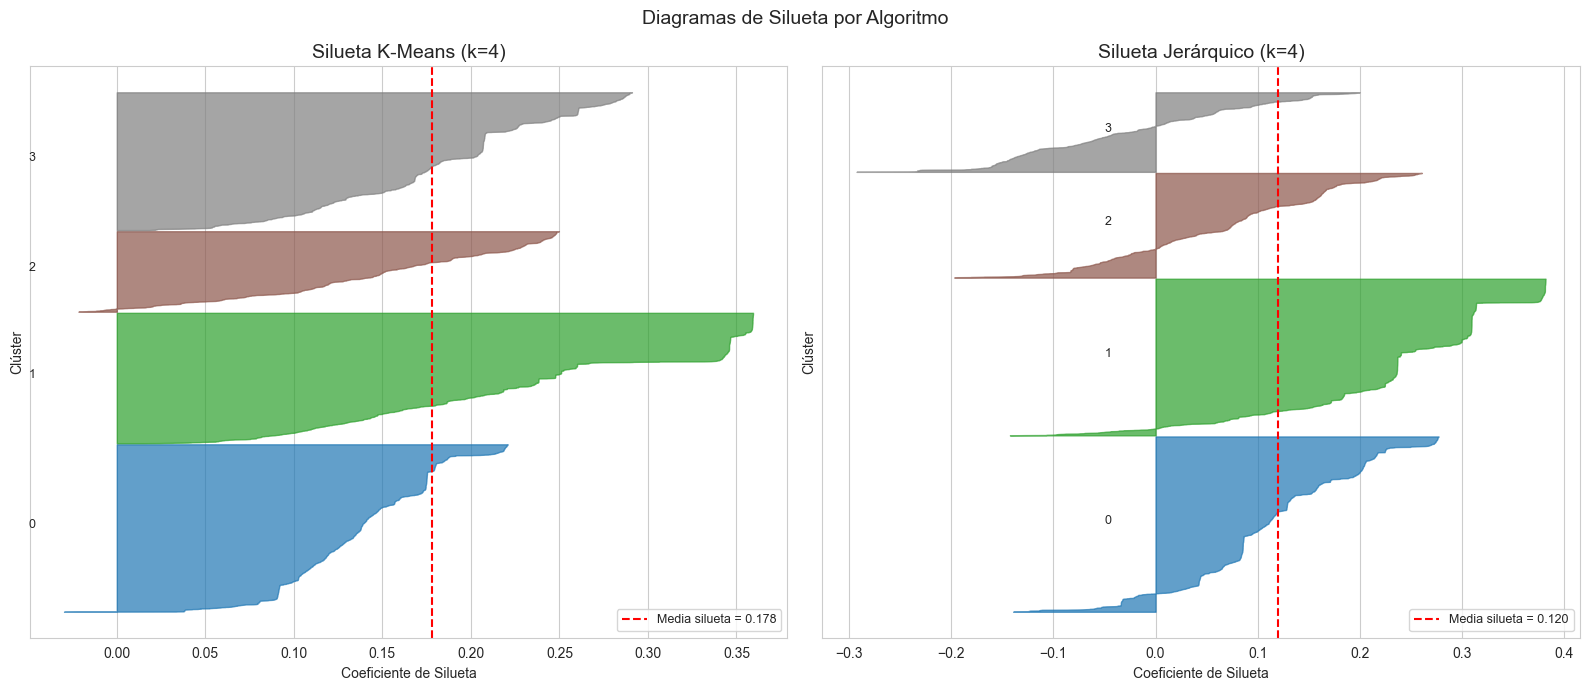

In [24]:
# Se grafican los diagramas de silueta por clúster para ambos algoritmos
def plot_silhouette(X, labels, title, ax):
    """Genera el diagrama de silueta para los clústeres dados."""
    sil_vals = silhouette_samples(X, labels, metric='euclidean')
    k = len(np.unique(labels))
    y_lower = 10
    cmap = cm.get_cmap('tab10')
    for i in sorted(np.unique(labels)):
        cluster_vals = np.sort(sil_vals[labels == i])
        size_i = len(cluster_vals)
        y_upper = y_lower + size_i
        color = cmap(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=9)
        y_lower = y_upper + 10

    avg_sil = sil_vals.mean()
    ax.axvline(x=avg_sil, color='red', linestyle='--', linewidth=1.5,
               label=f'Media silueta = {avg_sil:.3f}')
    ax.set_xlabel('Coeficiente de Silueta')
    ax.set_ylabel('Clúster')
    ax.set_title(title)
    ax.set_yticks([])
    ax.legend(loc='lower right', fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_silhouette(X_sil, labels_kmeans[idx_sil], f'Silueta K-Means (k={K_OPTIMAL})', axes[0])
plot_silhouette(X_sil, labels_hier[idx_sil],   f'Silueta Jerárquico (k={K_OPTIMAL})', axes[1])
plt.suptitle('Diagramas de Silueta por Algoritmo', fontsize=14)
plt.tight_layout()
plt.show()

#### Interpretación de la Silueta

El **coeficiente de silueta** de cada observación varía entre −1 y 1:
- **Cercano a 1**: la observación está bien asignada a su clúster (compacto y separado).
- **Cercano a 0**: la observación está en la frontera entre dos clústeres.
- **Negativo**: la observación probablemente está asignada al clúster incorrecto.

| Algoritmo | Score de Silueta | Evaluación |
|---|---|---|
| **K-Means** | **0.1783** | ✓ Mejor — estructura débil pero consistente |
| Jerárquico (Ward) | 0.1195 | ✗ Inferior — varios clústeres con coeficientes negativos |

Ambos puntajes caen en el rango **< 0.25 → "sin estructura fuerte"**, lo cual es esperable en este dataset por dos razones:

1. **Alta dimensionalidad (28 features):** A medida que aumentan las dimensiones, el concepto de distancia euclidiana se diluye (_curse of dimensionality_), reduciendo los valores de silueta incluso cuando los grupos son reales.
2. **Heterogeneidad intrínseca:** El 60% de las películas tienen presupuesto=0, lo que concentra buena parte de los datos en un subespacio del feature space y produce fronteras difusas.

**Diagnóstico por algoritmo:**

- **K-Means (silueta=0.178):** Todos los clústeres tienen coeficientes _predominantemente positivos_ y superan la media global. Los 4 grupos son razonablemente compactos. Las colas negativas en el clúster 0 indican que aún hay observaciones en la frontera, pero no hay desasignaciones masivas.

- **Jerárquico Ward (silueta=0.120):** Los clústeres 0, 2 y 3 presentan grandes proporciones de coeficientes negativos (valores de hasta −0.30), indicando que el algoritmo Ward asignó mal un número significativo de observaciones. Esto es consecuencia de que Ward optimiza varianza intra-clúster de forma greedy sobre la muestra, y al escalar al dataset completo pierde cohesión.

**Decisión:** Se utiliza **K-Means** para la interpretación de grupos (sección 1.6) por tener mayor calidad de agrupamiento medida con silueta.

In [25]:
# Se determina el mejor algoritmo y se asignan las etiquetas definitivas
if sil_km >= sil_hier:
    BEST_ALGO = 'K-Means'
    labels_best = labels_kmeans
    df_raw['cluster_best'] = labels_kmeans
else:
    BEST_ALGO = 'Jerárquico (Ward)'
    labels_best = labels_hier
    df_raw['cluster_best'] = labels_hier

print(f'Algoritmo seleccionado para interpretación: {BEST_ALGO}')
print(f'Score de silueta: {max(sil_km, sil_hier):.4f}')

Algoritmo seleccionado para interpretación: K-Means
Score de silueta: 0.1783


---
### 1.6 Interpretación de los Grupos

In [26]:
# Se prepara un dataframe con las variables de clustering y la etiqueta del mejor algoritmo
df_interp = df_cluster.copy()
df_interp['cluster'] = labels_best
df_interp['genres_str']       = df_raw['genres'].values
df_interp['originalLanguage'] = df_raw['originalLanguage'].values
df_interp['title']            = df_raw['title'].values

# Medidas de tendencia central por clúster — variables continuas clave
num_cols = [
    'popularity', 'budget', 'revenue', 'runtime',
    'voteAvg', 'voteCount', 'genresAmount',
    'castWomenAmount', 'castMenAmount',
    'maxActorsPopularity', 'director_freq'
]

summary = df_interp.groupby('cluster')[num_cols].agg(['mean', 'median']).round(2)
print(f'Resumen estadístico por clúster ({BEST_ALGO}):')
summary


Resumen estadístico por clúster (K-Means):


popularity              budget              revenue        runtime  \
              mean median         mean  median         mean median    mean   
cluster                                                                      
0            36.99  11.97  14806902.04     0.0  48754014.05    0.0   66.41   
1            11.29   0.07    762462.06     0.0   2587791.85    0.0   40.55   
2            40.57  17.83  15504280.06  4000.0  40345019.02    0.0   91.50   
3            18.48   9.64   7195721.99     0.0  21850942.17    0.0   73.73   

               voteAvg         ... genresAmount        castWomenAmount         \
        median    mean median  ...         mean median            mean median   
cluster                        ...                                              
0         84.0    4.03    5.6  ...         1.84    2.0         5687.55    2.0   
1         13.0    2.18    0.0  ...         1.30    1.0         3663.64    0.0   
2         98.0    5.43    6.1  ...         2.88    3.0         1513.89    4.0   
3         94.0    4.16    6.0  ...         2.12    2.0         1962.53    3.0   

        castMenAmount        maxActorsPopularity        director_freq         
                 mean median                mean median          mean median  
cluster                                                                       
0             7454.62    4.0               13.12   8.55         56.33    1.0  
1            11192.56    0.0                3.09   0.04        106.91    1.0  
2             5838.39    9.0               19.71  18.72         10.18    2.0  
3             7627.10    4.0               12.44   6.67         16.18    1.0  

[4 rows x 22 columns]

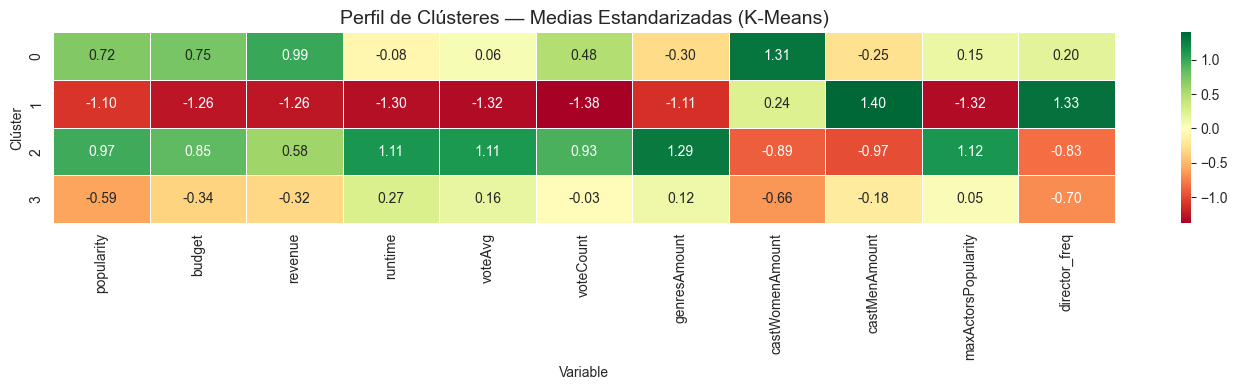

In [27]:
# Se grafica el perfil de cada clúster usando medias normalizadas (radar no aplica bien a pandas)
# Se usa un heatmap de medias estandarizadas por variable
cluster_means = df_interp.groupby('cluster')[num_cols].mean()
cluster_means_std = (cluster_means - cluster_means.mean()) / cluster_means.std()

fig, ax = plt.subplots(figsize=(14, max(4, K_OPTIMAL)))
sns.heatmap(
    cluster_means_std,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title(f'Perfil de Clústeres — Medias Estandarizadas ({BEST_ALGO})', fontsize=14)
ax.set_xlabel('Variable')
ax.set_ylabel('Clúster')
plt.tight_layout()
plt.show()

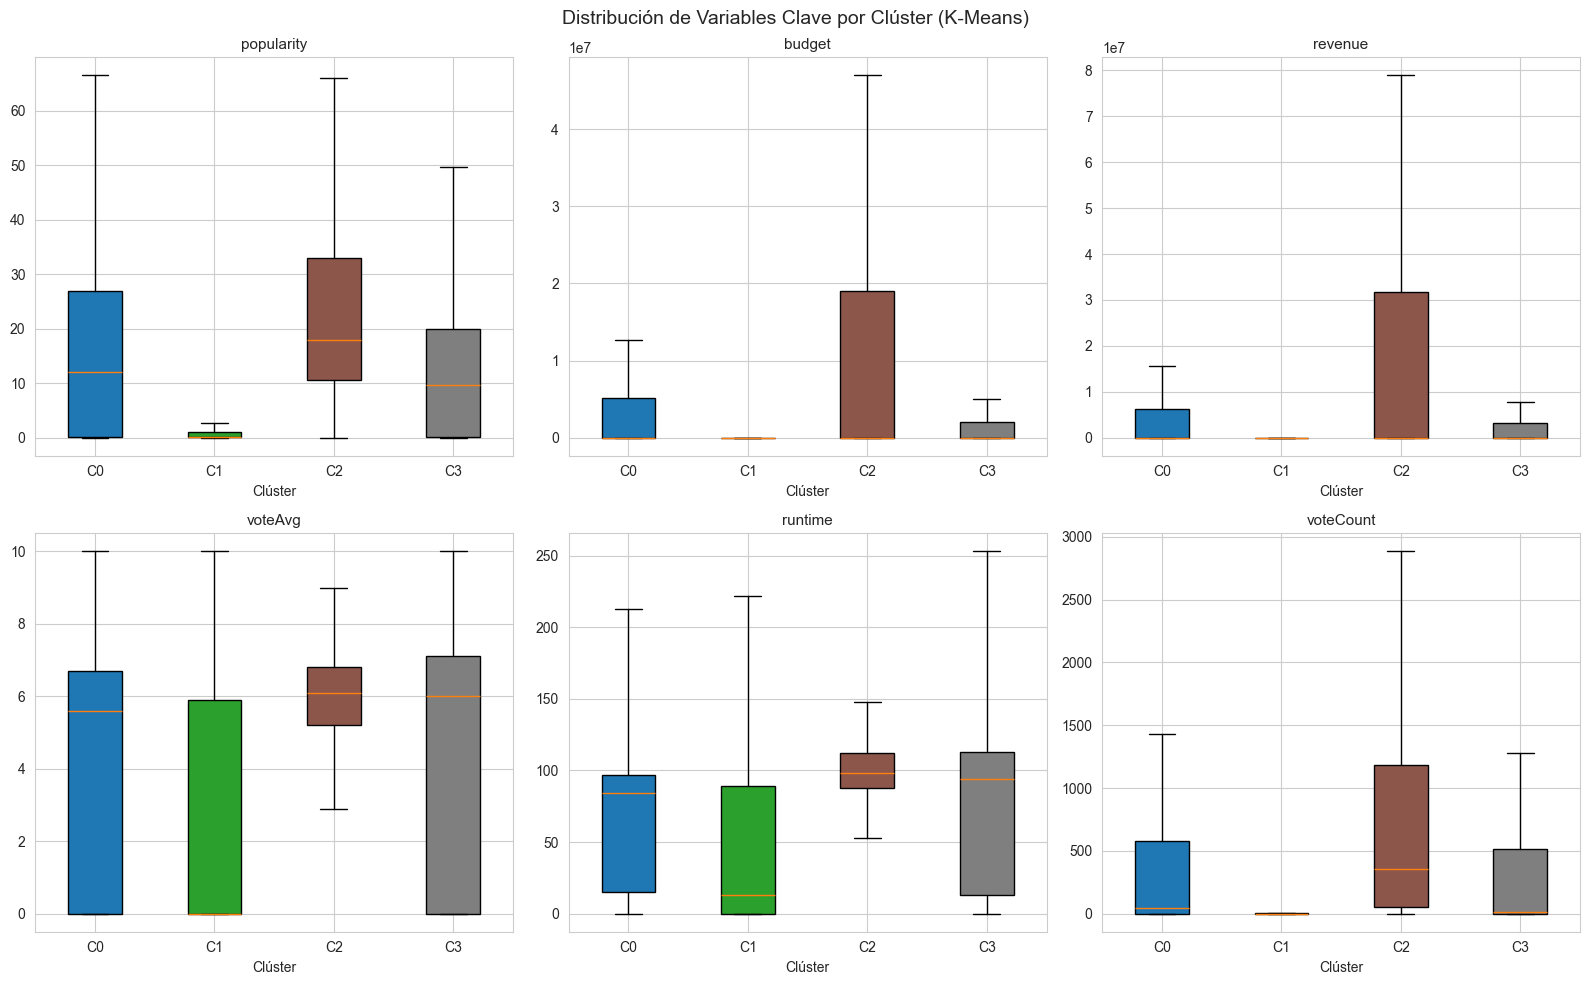

In [28]:
# Distribución de variables continuas clave por clúster (boxplots)
key_vars = ['popularity', 'budget', 'revenue', 'voteAvg', 'runtime', 'voteCount']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    data = [df_interp.loc[df_interp['cluster'] == k, var].values for k in sorted(df_interp['cluster'].unique())]
    bp = axes[i].boxplot(data, patch_artist=True, notch=False, showfliers=False)
    for patch, color in zip(bp['boxes'], [cm.tab10(j/K_OPTIMAL) for j in range(K_OPTIMAL)]):
        patch.set_facecolor(color)
    axes[i].set_title(var, fontsize=11)
    axes[i].set_xlabel('Clúster')
    axes[i].set_xticklabels([f'C{k}' for k in sorted(df_interp['cluster'].unique())])

plt.suptitle(f'Distribución de Variables Clave por Clúster ({BEST_ALGO})', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# Tabla de frecuencias de géneros por clúster
from collections import Counter

print('=== Top 5 géneros por clúster ===')
for k in sorted(df_interp['cluster'].unique()):
    genres_list = (
        df_interp.loc[df_interp['cluster'] == k, 'genres_str']
        .dropna()
        .str.split('|')
        .explode()
        .str.strip()
    )
    genres_list = genres_list[genres_list != '']
    counts = Counter(genres_list)
    print(f'\nClúster {k} (n={df_interp[df_interp["cluster"]==k].shape[0]:,}):')
    for genre, cnt in counts.most_common(5):
        print(f'  {genre}: {cnt:,}')

=== Top 5 géneros por clúster ===

Clúster 0 (n=6,420):
  Comedy: 2,402
  Family: 1,128
  Adventure: 1,061
  Action: 1,049
  Animation: 1,043

Clúster 1 (n=4,872):
  Documentary: 1,327
  Comedy: 1,057
  Animation: 685
  Action: 477
  Fantasy: 398

Clúster 2 (n=3,198):
  Thriller: 3,199
  Drama: 1,163
  Action: 1,049
  Horror: 994
  Crime: 817

Clúster 3 (n=5,393):
  Drama: 5,393
  Comedy: 1,136
  Romance: 1,109
  Action: 466
  History: 373


In [30]:
# Distribución del idioma original por clúster
print('=== Top 5 idiomas originales por clúster ===')
for k in sorted(df_interp['cluster'].unique()):
    lang_counts = (
        df_interp.loc[df_interp['cluster'] == k, 'originalLanguage']
        .value_counts()
        .head(5)
    )
    print(f'\nClúster {k}:')
    for lang, cnt in lang_counts.items():
        print(f'  {lang}: {cnt:,}')

=== Top 5 idiomas originales por clúster ===

Clúster 0:
  en: 6,419
  ja: 1

Clúster 1:
  es: 780
  fr: 731
  ja: 578
  pt: 407
  de: 318

Clúster 2:
  en: 2,594
  es: 120
  fr: 67
  ko: 58
  ja: 54

Clúster 3:
  en: 2,948
  es: 338
  fr: 296
  ja: 235
  pt: 185


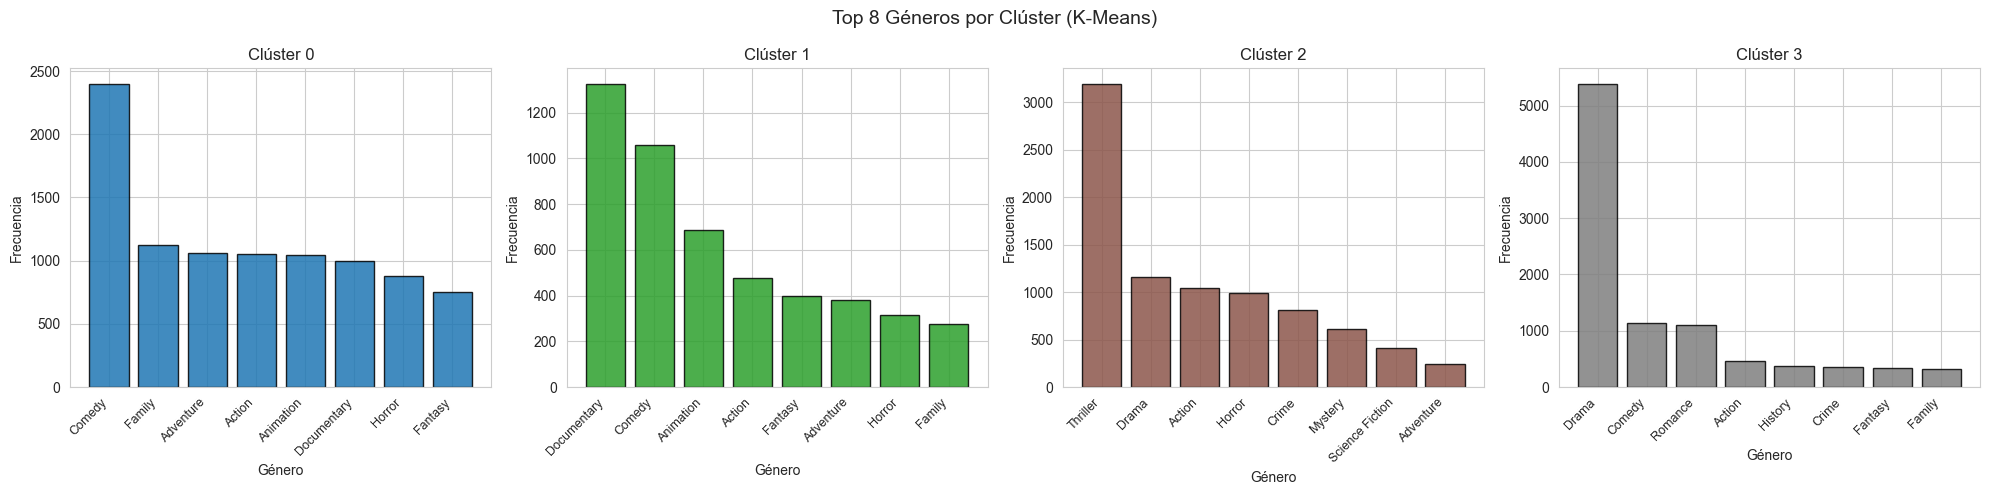

In [31]:
# Se grafican los géneros más frecuentes por clúster en un gráfico de barras
cluster_ids = sorted(df_interp['cluster'].unique())
n_clusters = len(cluster_ids)

fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5), sharey=False)
if n_clusters == 1:
    axes = [axes]

for ax, k in zip(axes, cluster_ids):
    genres_list = (
        df_interp.loc[df_interp['cluster'] == k, 'genres_str']
        .dropna()
        .str.split('|')
        .explode()
        .str.strip()
    )
    genres_list = genres_list[genres_list != '']

    if genres_list.empty:
        ax.set_title(f'Clúster {k}\n(sin datos de género)', fontsize=11)
        ax.set_visible(True)
        continue

    top = pd.Series(Counter(genres_list)).sort_values(ascending=False).head(8)

    # Se usa ax.bar() directamente para compatibilidad con pandas 3.x
    ax.bar(range(len(top)), top.values, color=cm.tab10(k / n_clusters),
           edgecolor='black', alpha=0.85)
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels(top.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'Clúster {k}', fontsize=12)
    ax.set_xlabel('Género')
    ax.set_ylabel('Frecuencia')

plt.suptitle(f'Top 8 Géneros por Clúster ({BEST_ALGO})', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
# Resumen ejecutivo por clúster
print(f'\n{"="*60}')
print(f'RESUMEN EJECUTIVO — {BEST_ALGO}  (K={K_OPTIMAL})')
print(f'{"="*60}')

for k in sorted(df_interp['cluster'].unique()):
    sub = df_interp[df_interp['cluster'] == k]
    print(f'\n--- Clúster {k} ({sub.shape[0]:,} películas) ---')
    print(f'  Popularidad media:      {sub["popularity"].mean():.2f}')
    print(f'  Presupuesto medio:      ${sub["budget"].mean():,.0f}')
    print(f'  Ingreso medio:          ${sub["revenue"].mean():,.0f}')
    print(f'  Duración media (min):   {sub["runtime"].mean():.1f}')
    print(f'  Promedio de votos:      {sub["voteAvg"].mean():.2f}')
    print(f'  Núm. votos medio:       {sub["voteCount"].mean():.0f}')
    print(f'  Tamaño elenco medio:    {sub["actorsAmount"].mean():.1f}')


RESUMEN EJECUTIVO — K-Means  (K=4)

--- Clúster 0 (6,420 películas) ---
  Popularidad media:      36.99
  Presupuesto medio:      $14,806,902
  Ingreso medio:          $48,754,014
  Duración media (min):   66.4
  Promedio de votos:      4.03
  Núm. votos medio:       917
  Tamaño elenco medio:    1686.7

--- Clúster 1 (4,872 películas) ---
  Popularidad media:      11.29
  Presupuesto medio:      $762,462
  Ingreso medio:          $2,587,792
  Duración media (min):   40.6
  Promedio de votos:      2.18
  Núm. votos medio:       62
  Tamaño elenco medio:    2158.0

--- Clúster 2 (3,198 películas) ---
  Popularidad media:      40.57
  Presupuesto medio:      $15,504,280
  Ingreso medio:          $40,345,019
  Duración media (min):   91.5
  Promedio de votos:      5.43
  Núm. votos medio:       1120
  Tamaño elenco medio:    23.3

--- Clúster 3 (5,393 películas) ---
  Popularidad media:      18.48
  Presupuesto medio:      $7,195,722
  Ingreso medio:          $21,850,942
  Duración media

#### 1.6 Interpretación de los Grupos — K-Means (K=4)

Los cuatro clústeres identificados presentan perfiles diferenciados en variables de presupuesto, recaudación, popularidad, duración, géneros predominantes e idioma original. A continuación se describe cada grupo con base en las estadísticas obtenidas.

---

### Clúster 0 — "Entretenimiento Familiar Anglófono" (n=6,420 · 32.3%)

| Variable | Media | Mediana |
|---|---|---|
| Popularidad | 36.99 | 11.97 |
| Presupuesto | $14,806,902 | $0 |
| Ingreso | $48,754,014 | $0 |
| Duración (min) | 66.4 | 84 |
| Promedio de votos | 4.03 | 5.6 |
| Número de votos | 917 | 189 |

**Géneros dominantes:** Comedy, Family, Adventure, Action, Animation.  
**Idioma:** prácticamente 100% inglés (6,419/6,420 películas).  
**Directores:** frecuencia media alta (56.3), indicando directores con filmografías prolíficas.  
**Actores:** `maxActorsPopularity` media de 13.1, nivel de reconocimiento moderado.

La mediana de presupuesto e ingreso en $0 revela que gran parte del grupo no tiene datos económicos registrados, pero el heatmap estandarizado muestra que este clúster supera ampliamente a los demás en revenue (+0.99σ), budget (+0.75σ) y popularity (+0.72σ). Se trata del segmento de mayor escala comercial, orientado al mercado de habla inglesa con géneros de amplio atractivo familiar.

---

### Clúster 1 — "Contenido Marginal / Cortometrajes Internacionales" (n=4,872 · 24.5%)

| Variable | Media | Mediana |
|---|---|---|
| Popularidad | 11.29 | 0.07 |
| Presupuesto | $762,462 | $0 |
| Ingreso | $2,587,792 | $0 |
| Duración (min) | 40.6 | 13 |
| Promedio de votos | 2.18 | 0.0 |
| Número de votos | 62 | 2 |

**Géneros dominantes:** Documentary, Comedy, Animation, Action, Fantasy.  
**Idioma:** sin predominancia inglesa; los idiomas más frecuentes son español (780), francés (731), japonés (578), portugués (407) y alemán (318).  
**Directores:** frecuencia más alta (106.9), lo que apunta a directores con catálogos muy extensos (posiblemente productoras de contenido seriado o animación).  
**Actores:** `maxActorsPopularity` mínima (3.09), lo que confirma que los actores son poco conocidos.

El heatmap estandarizado muestra valores consistentemente negativos en todas las variables clave (entre −1.1 y −1.4σ). La duración mediana de 13 minutos sugiere que una fracción significativa corresponde a cortometrajes o episodios de series. Este clúster agrupa el contenido de menor tracción comercial y distribución limitada.

---

### Clúster 2 — "Cine de Género Anglófono con Actores Populares" (n=3,198 · 16.1%)

| Variable | Media | Mediana |
|---|---|---|
| Popularidad | 40.57 | 17.83 |
| Presupuesto | $15,504,280 | $4,000 |
| Ingreso | $40,345,019 | $0 |
| Duración (min) | 91.5 | 98 |
| Promedio de votos | 5.43 | 6.1 |
| Número de votos | 1,120 | 408 |

**Géneros dominantes:** Thriller, Drama, Action, Horror, Crime — género espectacular por excelencia.  
**Idioma:** 81% inglés (2,594 de 3,198).  
**Actores:** `maxActorsPopularity` más alta de todos los clústeres (19.71), con actores de amplio reconocimiento.  
**Directores:** menor frecuencia (10.18), indicando directores más especializados o menos prolíficos.

El heatmap muestra puntaje alto en `genresAmount` (+1.29σ), `voteAvg` y `runtime` (+1.11σ), y `maxActorsPopularity` (+1.12σ). Es el clúster mejor valorado por el público (voteAvg 5.43) y con la duración mediana más próxima al estándar cinematográfico (98 min). Refléja el segmento de thriller/horror anglófono con reparto conocido que genera audiencia sólida y puntuaciones más altas.

---

### Clúster 3 — "Drama Internacional de Bajo-Mediano Presupuesto" (n=5,393 · 27.1%)

| Variable | Media | Mediana |
|---|---|---|
| Popularidad | 18.48 | 9.64 |
| Presupuesto | $7,195,722 | $0 |
| Ingreso | $21,850,942 | $0 |
| Duración (min) | 73.7 | 94 |
| Promedio de votos | 4.16 | 6.0 |
| Número de votos | 681 | 151 |

**Géneros dominantes:** Drama, Comedy, Romance, Action, History.  
**Idioma:** mixto — inglés 55% (2,948), seguido de español (338), francés (296), japonés (235) y portugués (185).  
**Actores:** elenco compacto (mediana castMenAmount=4, castWomenAmount=3).  
**Directores:** frecuencia media-baja (16.18).

Este clúster concentra producciones dramáticas y de comedia con mayor diversidad lingüística que el clúster 0, presupuesto moderado y alcance internacional. La presencia de Drama en el 100% de sus películas lo convierte en el segmento de drama por definición dentro del catálogo.

---

### Valor Estratégico para CineVision Studios

| Clúster | Nombre | Recomendación |
|---|---|---|
| **C0** | Entretenimiento Familiar Anglófono | Apostar por géneros Comedy/Family/Animation en inglés; alta conversión comercial relativa. |
| **C1** | Contenido Marginal Internacional | Mercado de largo plazo; explorar distribución digital en mercados hispanófonos/lusófonos. |
| **C2** | Cine de Género Anglófono | Invertir en Thriller/Horror con reparto reconocido para maximizar puntuación y retención de audiencia. |
| **C3** | Drama Internacional | Potencial en festivales y plataformas OTT; géneros Drama/Romance con producción contenida. |

In [33]:
# Se exportan los resultados con etiquetas de clúster
output_cols = ['id', 'title', 'originalLanguage', 'genres', 'budget', 'revenue',
               'popularity', 'voteAvg', 'voteCount', 'runtime', 'releaseYear',
               'cluster_kmeans', 'cluster_hier', 'cluster_best']

df_export = df_raw[[c for c in output_cols if c in df_raw.columns]].copy()
df_export.to_csv('movies_clustered.csv', index=False)
print('Archivo movies_clustered.csv exportado correctamente.')

Archivo movies_clustered.csv exportado correctamente.
